<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/SAM2/SAM%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Meu Drive
waterbodiesdataset.zip

In [ ]:
#bloco 1
"""
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

caminho_zip = "/content/drive/MyDrive/waterbodiesdataset.zip"

with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print('dataset carregado com sucesso')

pasta_dataset = '/content/dataset'
arquivos = os.listdir(pasta_dataset)
print(f'{len(arquivos)} arquivos/pastas encontrados')

for item in arquivos:
    print(f'- {item}')
"""

Mounted at /content/drive
dataset carregado com sucesso
1 arquivos/pastas encontrados
- Water Bodies Dataset


In [ ]:
# bloco 1
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

caminho_zip = "/content/drive/MyDrive/waterbodiesdataset.zip"

with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print('dataset carregado com sucesso')

# acessar a pasta correta
pasta_dataset = '/content/dataset/Water Bodies Dataset'
arquivos = os.listdir(pasta_dataset)
print(f'{len(arquivos)} arquivos/pastas encontrados em "Water Bodies Dataset":')

for item in arquivos:
    print(f'- {item}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset carregado com sucesso
2 arquivos/pastas encontrados em "Water Bodies Dataset":
- Masks
- Images


In [ ]:
#métricas com sam
!pip install segment-anything opencv-python torch torchvision matplotlib tqdm

import os
import cv2
import numpy as np
import torch
import zipfile
from segment_anything import sam_model_registry, SamPredictor
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# verificar gpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'usando dispositivo: {device}')

# baixar modelo sam
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# carregar modelo
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)
predictor = SamPredictor(sam)

# extrair dataset
caminho_zip = "/content/drive/MyDrive/waterbodiesdataset.zip"
with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print('dataset carregado')

# caminhos das pastas
pasta_imagens = '/content/dataset/Water Bodies Dataset/Images'
pasta_mascaras = '/content/dataset/Water Bodies Dataset/Masks'

# listar arquivos
imagens = sorted([f for f in os.listdir(pasta_imagens) if f.endswith(('.png', '.jpg', '.jpeg'))])
mascaras = sorted([f for f in os.listdir(pasta_mascaras) if f.endswith(('.png', '.jpg', '.jpeg'))])

print(f'imagens: {len(imagens)}')
print(f'mascaras: {len(mascaras)}')

# função para calcular métricas
def calcular_metricas(mascara_pred, mascara_gt):
    pred = mascara_pred > 0.5
    gt = mascara_gt > 0.5

    intersecao = np.logical_and(pred, gt).sum()
    uniao = np.logical_or(pred, gt).sum()

    total_pixels = pred.size
    acertos = (pred == gt).sum()
    acuracia = acertos / total_pixels

    iou = intersecao / uniao if uniao > 0 else 0

    return acuracia, iou

# processar imagens
acuracia_total = []
iou_total = []

for img_nome, mask_nome in tqdm(zip(imagens, mascaras), total=len(imagens)):
    img_path = os.path.join(pasta_imagens, img_nome)
    mask_path = os.path.join(pasta_mascaras, mask_nome)

    imagem = cv2.imread(img_path)
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    mascara_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mascara_gt = mascara_gt / 255.0

    predictor.set_image(imagem)

    h, w = imagem.shape[:2]
    ponto = np.array([[w//2, h//2]])
    rotulo = np.array([1])

    mascaras_pred, scores, logits = predictor.predict(
        point_coords=ponto,
        point_labels=rotulo,
        multimask_output=False
    )

    mascara_pred = mascaras_pred[0]

    if mascara_pred.shape != mascara_gt.shape:
        mascara_pred = cv2.resize(mascara_pred, (mascara_gt.shape[1], mascara_gt.shape[0]))

    acc, iou = calcular_metricas(mascara_pred, mascara_gt)
    acuracia_total.append(acc)
    iou_total.append(iou)

    print(f'{img_nome}: acc={acc:.4f}, iou={iou:.4f}')

print(f'\nresultados finais:')
print(f'acuracia media: {np.mean(acuracia_total):.4f}')
print(f'iou medio: {np.mean(iou_total):.4f}')
print(f'desvio padrao acuracia: {np.std(acuracia_total):.4f}')
print(f'desvio padrao iou: {np.std(iou_total):.4f}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
usando dispositivo: cuda
dataset carregado
imagens: 2841
mascaras: 2841


  0%|          | 1/2841 [00:03<2:57:22,  3.75s/it]

water_body_1.jpg: acc=0.1286, iou=0.1192


  0%|          | 2/2841 [00:05<2:10:27,  2.76s/it]

water_body_10.jpg: acc=0.5327, iou=0.1622


...

water_body_997.jpg: acc=0.9195, iou=0.6435


100%|█████████▉| 2840/2841 [1:58:32<00:02,  2.53s/it]

water_body_998.jpg: acc=0.7580, iou=0.0126


100%|██████████| 2841/2841 [1:58:34<00:00,  2.50s/it]

water_body_999.jpg: acc=0.6698, iou=0.4158

resultados finais:
acuracia media: 0.6806
iou medio: 0.4273
desvio padrao acuracia: 0.2944
desvio padrao iou: 0.3698


estatísticas detalhadas:
acuracia - min: 0.0000, max: 1.0000
iou - min: 0.0000, max: 1.0000

melhor caso - imagem: water_body_7052.jpg
  acuracia: 1.0000, iou: 1.0000
pior caso - imagem: water_body_1018.jpg
  acuracia: 0.8560, iou: 0.0000


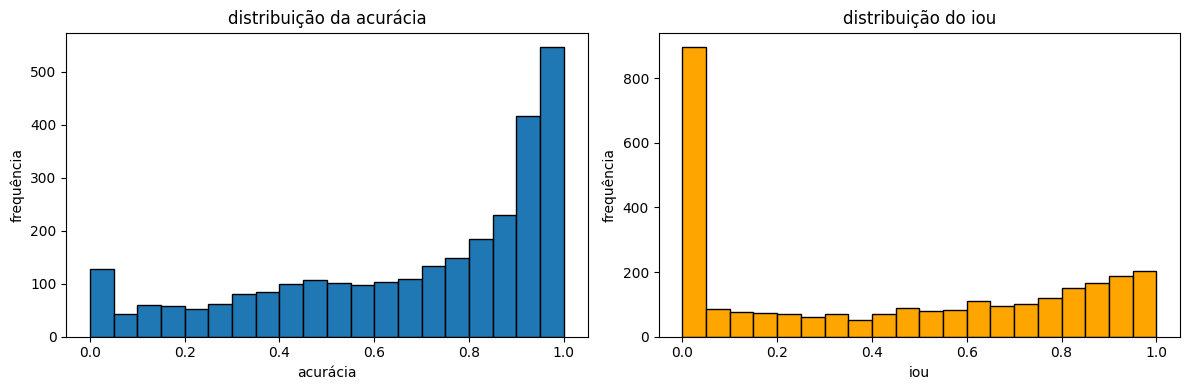

In [ ]:
# bloco 2 - análise detalhada dos resultados
import matplotlib.pyplot as plt

# estatísticas detalhadas
acuracia_array = np.array(acuracia_total)
iou_array = np.array(iou_total)

print('estatísticas detalhadas:')
print(f'acuracia - min: {acuracia_array.min():.4f}, max: {acuracia_array.max():.4f}')
print(f'iou - min: {iou_array.min():.4f}, max: {iou_array.max():.4f}')

# identificar melhores e piores casos
melhor_idx = np.argmax(iou_array)
pior_idx = np.argmin(iou_array)

print(f'\nmelhor caso - imagem: {imagens[melhor_idx]}')
print(f'  acuracia: {acuracia_array[melhor_idx]:.4f}, iou: {iou_array[melhor_idx]:.4f}')
print(f'pior caso - imagem: {imagens[pior_idx]}')
print(f'  acuracia: {acuracia_array[pior_idx]:.4f}, iou: {iou_array[pior_idx]:.4f}')

# histogramas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(acuracia_array, bins=20, edgecolor='black')
axes[0].set_title('distribuição da acurácia')
axes[0].set_xlabel('acurácia')
axes[0].set_ylabel('frequência')

axes[1].hist(iou_array, bins=20, edgecolor='black', color='orange')
axes[1].set_title('distribuição do iou')
axes[1].set_xlabel('iou')
axes[1].set_ylabel('frequência')

plt.tight_layout()
plt.show()

melhor resultado:


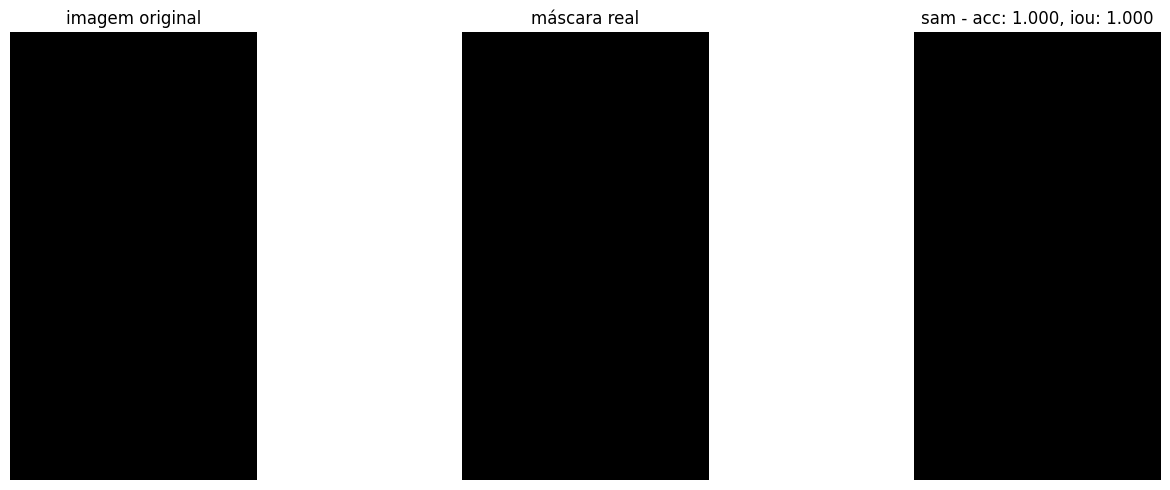

pior resultado:


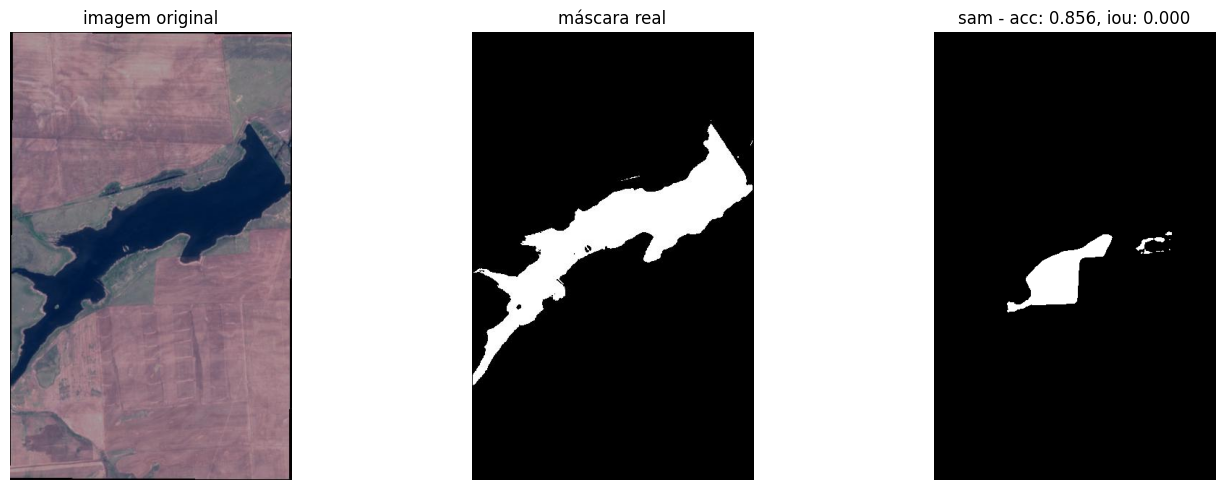

exemplo aleatório 1:


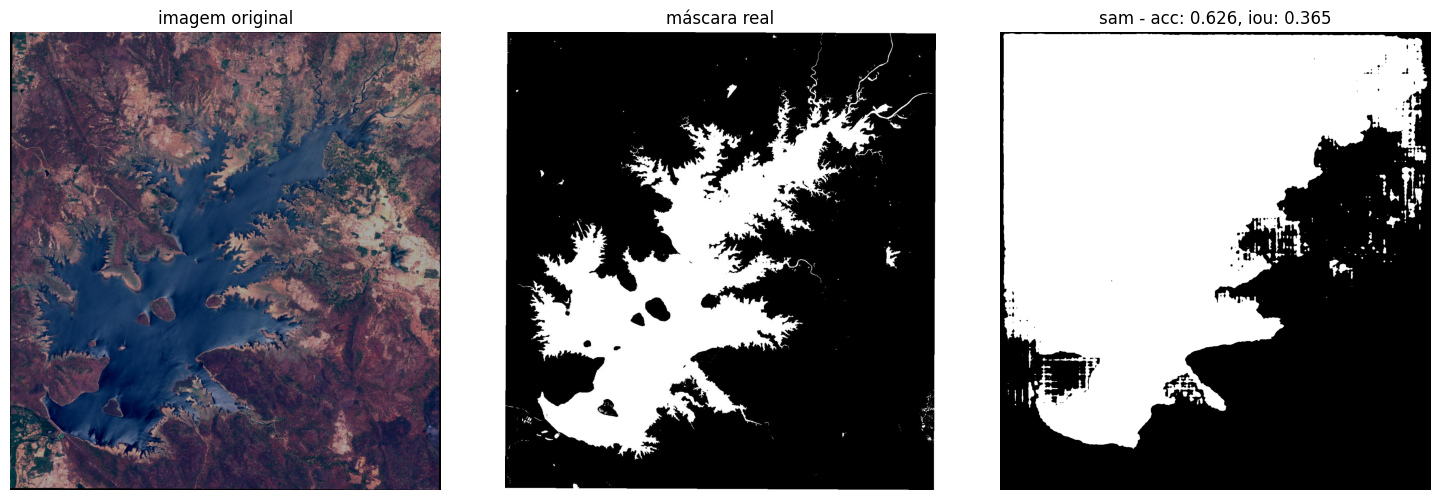

exemplo aleatório 2:


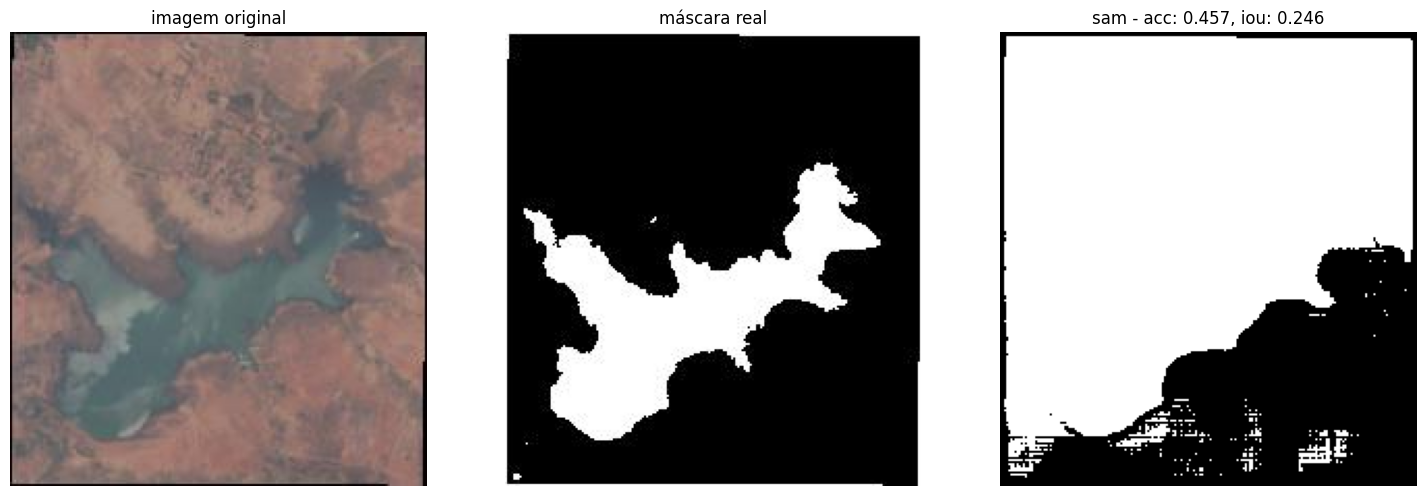

exemplo aleatório 3:


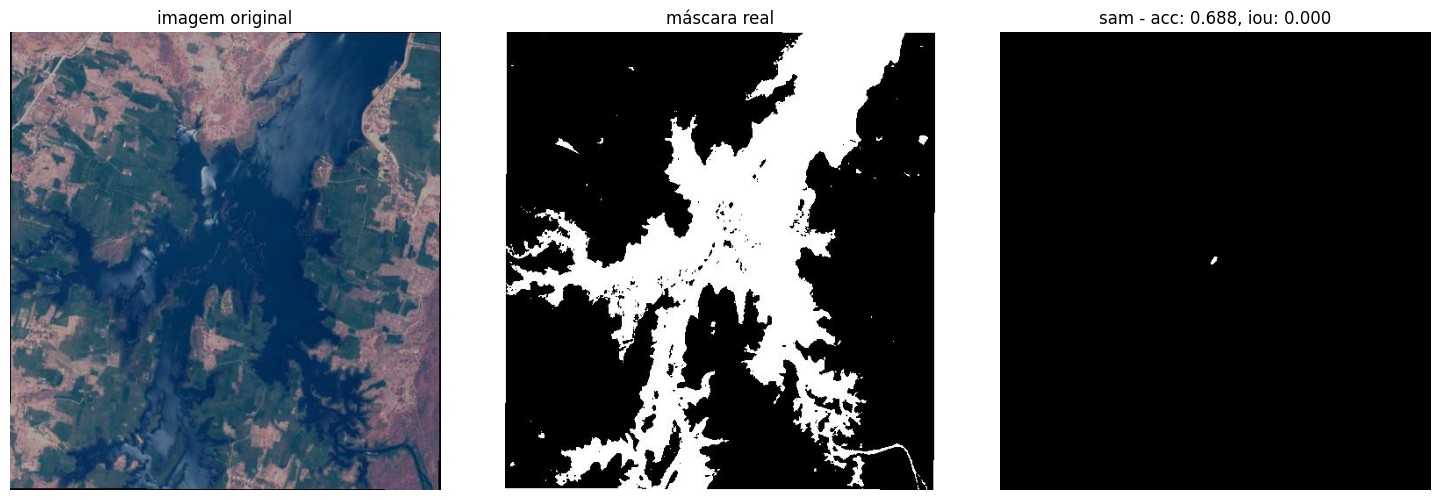

In [ ]:
# bloco 3 - visualização de exemplos
import matplotlib.pyplot as plt

def visualizar_resultado(idx):
    img_path = os.path.join(pasta_imagens, imagens[idx])
    mask_path = os.path.join(pasta_mascaras, mascaras[idx])

    imagem = cv2.imread(img_path)
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    mascara_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # gerar máscara com sam
    predictor.set_image(imagem)
    h, w = imagem.shape[:2]
    ponto = np.array([[w//2, h//2]])
    rotulo = np.array([1])

    mascaras_pred, _, _ = predictor.predict(
        point_coords=ponto,
        point_labels=rotulo,
        multimask_output=False
    )
    mascara_pred = mascaras_pred[0]

    if mascara_pred.shape != mascara_gt.shape:
        mascara_pred = cv2.resize(mascara_pred, (mascara_gt.shape[1], mascara_gt.shape[0]))

    # criar figura
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(imagem)
    axes[0].set_title('imagem original')
    axes[0].axis('off')

    axes[1].imshow(mascara_gt, cmap='gray')
    axes[1].set_title('máscara real')
    axes[1].axis('off')

    axes[2].imshow(mascara_pred, cmap='gray')
    axes[2].set_title(f'sam - acc: {acuracia_total[idx]:.3f}, iou: {iou_total[idx]:.3f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# visualizar melhores e piores
print('melhor resultado:')
visualizar_resultado(melhor_idx)

print('pior resultado:')
visualizar_resultado(pior_idx)

# visualizar alguns aleatórios
indices_aleatorios = np.random.choice(len(imagens), size=3, replace=False)
for i, idx in enumerate(indices_aleatorios):
    print(f'exemplo aleatório {i+1}:')
    visualizar_resultado(idx)

In [ ]:
# bloco 4 - teste com diferentes prompts
# testando múltiplos pontos para melhorar a segmentação

def segmentar_com_pontos(imagem, pontos):
    predictor.set_image(imagem)
    pontos = np.array(pontos)
    rotulos = np.ones(len(pontos))

    mascaras, scores, _ = predictor.predict(
        point_coords=pontos,
        point_labels=rotulos,
        multimask_output=True
    )

    # pegar a máscara com maior score
    melhor_idx = np.argmax(scores)
    return mascaras[melhor_idx]

# testar em algumas imagens
n_testes = min(5, len(imagens))
print(f'testando diferentes estratégias em {n_testes} imagens')

resultados_ponto_central = []
resultados_multipontos = []

for i in range(n_testes):
    img_path = os.path.join(pasta_imagens, imagens[i])
    mask_path = os.path.join(pasta_mascaras, mascaras[i])

    imagem = cv2.imread(img_path)
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
    mascara_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0

    h, w = imagem.shape[:2]

    # estratégia 1: ponto central
    predictor.set_image(imagem)
    ponto_central = np.array([[w//2, h//2]])
    mascaras_pred, _, _ = predictor.predict(
        point_coords=ponto_central,
        point_labels=np.array([1]),
        multimask_output=False
    )
    mascara_central = mascaras_pred[0]

    # estratégia 2: múltiplos pontos (centro + bordas)
    pontos_multiplos = [
        [w//2, h//2],  # centro
        [w//4, h//4],  # canto superior esquerdo
        [3*w//4, h//4],  # canto superior direito
        [w//4, 3*h//4],  # canto inferior esquerdo
        [3*w//4, 3*h//4]  # canto inferior direito
    ]
    mascara_multipontos = segmentar_com_pontos(imagem, pontos_multiplos)

    # redimensionar se necessário
    if mascara_central.shape != mascara_gt.shape:
        mascara_central = cv2.resize(mascara_central, (mascara_gt.shape[1], mascara_gt.shape[0]))
        mascara_multipontos = cv2.resize(mascara_multipontos, (mascara_gt.shape[1], mascara_gt.shape[0]))

    _, iou_central = calcular_metricas(mascara_central, mascara_gt)
    _, iou_multipontos = calcular_metricas(mascara_multipontos, mascara_gt)

    resultados_ponto_central.append(iou_central)
    resultados_multipontos.append(iou_multipontos)

    print(f'imagem {imagens[i]}: iou central={iou_central:.4f}, iou multipontos={iou_multipontos:.4f}')

print(f'\nmédia iou central: {np.mean(resultados_ponto_central):.4f}')
print(f'média iou multipontos: {np.mean(resultados_multipontos):.4f}')

testando diferentes estratégias em 5 imagens
imagem water_body_1.jpg: iou central=0.1192, iou multipontos=0.1194
imagem water_body_10.jpg: iou central=0.1622, iou multipontos=0.2577
imagem water_body_100.jpg: iou central=0.8726, iou multipontos=0.5571
imagem water_body_1000.jpg: iou central=0.5010, iou multipontos=0.1621
imagem water_body_1002.jpg: iou central=0.0825, iou multipontos=0.0809

média iou central: 0.3475
média iou multipontos: 0.2354


In [ ]:
# bloco 6 - especificação detalhada dos resultados

import pandas as pd
from datetime import datetime

print('='*60)
print('especificação dos resultados - sam no dataset water bodies')
print('='*60)

# 1. informações gerais
print('\n1. informações gerais:')
print(f'   total de imagens processadas: {len(imagens)}')
print(f'   dispositivo utilizado: {device}')
print(f'   modelo sam: vit_h')
print(f'   tipo de prompt: ponto central')

# 2. métricas principais
print('\n2. métricas principais:')
print(f'   acurácia média: {np.mean(acuracia_total):.4f} ({np.mean(acuracia_total)*100:.2f}%)')
print(f'   iou médio: {np.mean(iou_total):.4f} ({np.mean(iou_total)*100:.2f}%)')
print(f'   desvio padrão acurácia: {np.std(acuracia_total):.4f}')
print(f'   desvio padrão iou: {np.std(iou_total):.4f}')

# 3. percentis
print('\n3. percentis:')
percentis = [25, 50, 75, 90, 95]
print(f'   percentis iou:')
for p in percentis:
    valor = np.percentile(iou_total, p)
    print(f'      {p}%: {valor:.4f}')

print(f'\n   percentis acurácia:')
for p in percentis:
    valor = np.percentile(acuracia_total, p)
    print(f'      {p}%: {valor:.4f}')

# 4. distribuição por faixas
print('\n4. distribuição por faixas de iou:')
faixas = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
for min_f, max_f in faixas:
    count = sum(1 for iou in iou_total if min_f <= iou < max_f)
    pct = count / len(iou_total) * 100
    print(f'   {min_f:.1f} - {max_f:.1f}: {count} imagens ({pct:.1f}%)')

print('\n5. distribuição por faixas de acurácia:')
for min_f, max_f in faixas:
    count = sum(1 for acc in acuracia_total if min_f <= acc < max_f)
    pct = count / len(acuracia_total) * 100
    print(f'   {min_f:.1f} - {max_f:.1f}: {count} imagens ({pct:.1f}%)')

# 6. top 5 melhores e piores
print('\n6. top 5 melhores iou:')
melhores_indices = np.argsort(iou_total)[-5:][::-1]
for i, idx in enumerate(melhores_indices, 1):
    print(f'   {i}. {imagens[idx]}: iou={iou_total[idx]:.4f}, acc={acuracia_total[idx]:.4f}')

print('\n7. top 5 piores iou:')
piores_indices = np.argsort(iou_total)[:5]
for i, idx in enumerate(piores_indices, 1):
    print(f'   {i}. {imagens[idx]}: iou={iou_total[idx]:.4f}, acc={acuracia_total[idx]:.4f}')

# 7. análise estatística completa
print('\n8. análise estatística completa:')
print(f'   {pd.Series(iou_total).describe().to_string()}')

# 8. resumo
print('\n9. resumo consolidado:')
print(f'   {len([iou for iou in iou_total if iou >= 0.5])} imagens com iou >= 0.5 ({np.mean([iou >= 0.5 for iou in iou_total])*100:.1f}%)')
print(f'   {len([iou for iou in iou_total if iou >= 0.7])} imagens com iou >= 0.7 ({np.mean([iou >= 0.7 for iou in iou_total])*100:.1f}%)')
print(f'   {len([iou for iou in iou_total if iou >= 0.8])} imagens com iou >= 0.8 ({np.mean([iou >= 0.8 for iou in iou_total])*100:.1f}%)')
print(f'   {len([iou for iou in iou_total if iou < 0.3])} imagens com iou < 0.3 ({np.mean([iou < 0.3 for iou in iou_total])*100:.1f}%)')

# 9. salvar especificação em arquivo
timestamp = datetime.now().strftime('%y%m%d_%H%M%S')
arquivo_espec = f'especificacao_resultados_{timestamp}.txt'

with open(arquivo_espec, 'w') as f:
    f.write('especificação dos resultados - sam no dataset water bodies\n')
    f.write('='*60 + '\n\n')

    f.write(f'total de imagens: {len(imagens)}\n')
    f.write(f'dispositivo: {device}\n')
    f.write(f'modelo: sam vit_h\n')
    f.write(f'prompt: ponto central\n\n')

    f.write(f'acurácia média: {np.mean(acuracia_total):.4f} ({np.mean(acuracia_total)*100:.2f}%)\n')
    f.write(f'iou médio: {np.mean(iou_total):.4f} ({np.mean(iou_total)*100:.2f}%)\n')
    f.write(f'desvio padrão acurácia: {np.std(acuracia_total):.4f}\n')
    f.write(f'desvio padrão iou: {np.std(iou_total):.4f}\n\n')

    f.write('percentis iou:\n')
    for p in percentis:
        f.write(f'  {p}%: {np.percentile(iou_total, p):.4f}\n')

    f.write('\npercentis acurácia:\n')
    for p in percentis:
        f.write(f'  {p}%: {np.percentile(acuracia_total, p):.4f}\n')

    f.write('\ndistribuição iou:\n')
    for min_f, max_f in faixas:
        count = sum(1 for iou in iou_total if min_f <= iou < max_f)
        f.write(f'  {min_f:.1f}-{max_f:.1f}: {count} imagens\n')

    f.write('\ntop 5 melhores iou:\n')
    for i, idx in enumerate(melhores_indices, 1):
        f.write(f'  {i}. {imagens[idx]}: iou={iou_total[idx]:.4f}\n')

    f.write('\ntop 5 piores iou:\n')
    for i, idx in enumerate(piores_indices, 1):
        f.write(f'  {i}. {imagens[idx]}: iou={iou_total[idx]:.4f}\n')

print(f'\n\narquivo de especificação salvo: {arquivo_espec}')

# download
from google.colab import files
files.download(arquivo_espec)

especificação dos resultados - sam no dataset water bodies

1. informações gerais:
   total de imagens processadas: 2841
   dispositivo utilizado: cuda
   modelo sam: vit_h
   tipo de prompt: ponto central

2. métricas principais:
   acurácia média: 0.6806 (68.06%)
   iou médio: 0.4273 (42.73%)
   desvio padrão acurácia: 0.2944
   desvio padrão iou: 0.3698

3. percentis:
   percentis iou:
      25%: 0.0115
      50%: 0.4235
      75%: 0.7998
      90%: 0.9334
      95%: 0.9637

   percentis acurácia:
      25%: 0.4718
      50%: 0.7875
      75%: 0.9326
      90%: 0.9758
      95%: 0.9868

4. distribuição por faixas de iou:
   0.0 - 0.2: 1131 imagens (39.8%)
   0.2 - 0.4: 253 imagens (8.9%)
   0.4 - 0.6: 319 imagens (11.2%)
   0.6 - 0.8: 428 imagens (15.1%)
   0.8 - 1.0: 709 imagens (25.0%)

5. distribuição por faixas de acurácia:
   0.0 - 0.2: 287 imagens (10.1%)
   0.2 - 0.4: 279 imagens (9.8%)
   0.4 - 0.6: 405 imagens (14.3%)
   0.6 - 0.8: 494 imagens (17.4%)
   0.8 - 1.0: 1375 ima

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>